# STOFS-3D Coastal Boundary Integration

This notebook demonstrates how to use the `CoastalBoundary` class to download NOAA STOFS-3D-Atlantic coastal storm surge forecasts and write stage boundary conditions for HEC-RAS models.

**STOFS-3D-Atlantic** (Surge, Tide, and Overland Flow with 3D hydrodynamics) is NOAA's operational coastal storm surge forecast model:
- **Coverage**: U.S. Atlantic Coast, Gulf of Mexico, and Caribbean
- **Mesh**: Unstructured triangular mesh (~80 m nearshore to ~50 km offshore)
- **Forecast horizon**: 48 hours
- **Vertical datum**: NAVD88 (meters)
- **Cycles**: 00z, 06z, 12z, 18z UTC (4 cycles per day)
- **Data source**: NOAA NOMADS server (`https://nomads.ncep.noaa.gov/pub/data/nccf/com/stofs/prod`)

> **Note**: Download and extraction steps require internet access to NOAA NOMADS servers. Code cells that require internet access will gracefully skip and show expected output.

!pip install --upgrade ras-commander

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
# Set USE_LOCAL_SOURCE based on your setup:
#   True  = Use local source code (for developers editing ras-commander)
#   False = Use pip-installed package (for users)
# =============================================================================

USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

# -----------------------------------------------------------------------------
if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)  # Parent of examples/ = repo root
    if local_path not in sys.path:
        sys.path.insert(0, local_path)  # Insert at position 0 = highest priority
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

LOCAL SOURCE MODE: Loading from G:\GH\ras-commander-wt-run923/ras_commander


In [2]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from ras_commander.boundaries import CoastalBoundary

c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## What You'll Learn

- **Download STOFS-3D forecasts** from NOAA NOMADS using `CoastalBoundary.download_stofs3d()`
- **Extract water surface elevation (WSE)** at any coastal point using `CoastalBoundary.extract_wse_at_point()`
- **Create stage boundary conditions** for HEC-RAS using `CoastalBoundary.generate_stage_bc()`
- **Handle datum conversions** from NAVD88 meters to feet with optional datum adjustments
- **Check forecast availability** before downloading with `CoastalBoundary.check_availability()`

## STOFS-3D Overview

STOFS-3D-Atlantic uses an **unstructured triangular mesh** that adapts spatial resolution to coastal complexity:

| Zone | Approximate Resolution |
|------|------------------------|
| Nearshore (< 20 m depth) | ~80 m |
| Inner shelf | ~500 m - 2 km |
| Outer shelf | ~5 km |
| Deep ocean | ~50 km |

**Output types**:
- `points` - Time series at selected output points (faster, ~50 MB per file)
- `fields` - Gridded spatial output (larger, used for flood mapping)

**Temporal resolution**: Sub-hourly output (~6-minute intervals, ~1200 time steps per 48-hour forecast)

**Why it matters for HEC-RAS**: STOFS-3D provides physically consistent tidal and storm surge predictions that can be used directly as downstream stage boundary conditions, replacing manually estimated tidal curves or NOAA tidal predictions.

In [3]:
# Get STOFS-3D model information
info = CoastalBoundary.get_info()
print("STOFS-3D-Atlantic Information:")
for key, value in info.items():
    print(f"  {key}: {value}")

STOFS-3D-Atlantic Information:
  name: STOFS-3D-Atlantic (Surge and Tide Operational Forecast System)
  provider: NOAA / NOS / CO-OPS
  spatial_resolution: Variable (80m nearshore to 50km offshore)
  temporal_resolution: Hourly output
  coverage: US Atlantic and Gulf coasts
  forecast_horizon: 48 hours
  update_frequency: Every 6 hours (00z, 06z, 12z, 18z)
  format: NetCDF (field output), GRIB2 (surface fields)
  datum: NAVD88 (meters)
  variables: ['Water surface elevation (zeta/cwl)', 'Currents (u, v)', 'Temperature', 'Salinity']
  base_url: https://nomads.ncep.noaa.gov/pub/data/nccf/com/stofs/prod
  documentation: https://tidesandcurrents.noaa.gov/ofs/stofs3d/stofs3d.html


## Example 1: Gulf Coast (Galveston Bay)

Galveston Bay is an excellent test case for STOFS-3D integration:
- Low tidal range (~1-2 ft) makes storm surge the dominant water level driver
- Well-documented historical surge events (Hurricane Harvey, Ike)
- Many HEC-RAS models use Galveston Bay as downstream boundary

### Step 1: Check Data Availability

In [4]:
# Check whether the latest STOFS-3D cycle is available on NOMADS
try:
    available = CoastalBoundary.check_availability()
    print(f"Latest STOFS-3D cycle available: {available}")
except Exception as e:
    print(f"Availability check requires internet: {e}")

Latest STOFS-3D cycle available: False


### Step 2: Download STOFS-3D Forecast

In [5]:
# STOFS-3D sample data.
# Prefer the committed sample dataset (examples/data/stofs3d_gulf); only
# download from the network if it is missing. The committed file is never
# deleted by the cleanup cell below.
stofs_dir = Path("data/stofs3d_gulf")          # relative to examples/
if not stofs_dir.exists():
    alt = Path("examples/data/stofs3d_gulf")   # when run from the repo root
    if alt.exists():
        stofs_dir = alt
stofs_dir.mkdir(parents=True, exist_ok=True)

existing = sorted(stofs_dir.glob("*.nc"))
if existing:
    stofs_files = existing
    print(f"Using committed STOFS-3D sample data ({len(stofs_files)} file(s)) in {stofs_dir}")
    for f in stofs_files:
        print(f"  {f.name} ({f.stat().st_size / 1024 / 1024:.1f} MB)")
else:
    try:
        stofs_files = CoastalBoundary.download_stofs3d(
            output_dir=stofs_dir,
            file_type="points"  # Point data (faster, smaller than fields)
        )
        print(f"Downloaded {len(stofs_files)} STOFS-3D files")
        for f in stofs_files:
            print(f"  {f.name} ({f.stat().st_size / 1024 / 1024:.1f} MB)")
    except Exception as e:
        print(f"Download requires internet: {e}")
        print()
        print("Expected output:")
        print("  Downloaded 1-2 STOFS-3D NetCDF files")
        print("  stofs_3d_atl.t00z.points.cwl.nc (~50 MB)")
        stofs_files = []

Using committed STOFS-3D sample data (1 file(s)) in data\stofs3d_gulf
  stofs_3d_atl.t12z.points.cwl.temp.salt.vel.nc (5.3 MB)


### Step 3: Extract WSE at Galveston Bay Entrance

In [6]:
# Galveston Bay entrance coordinates
galveston_lat = 29.35
galveston_lon = -94.77

try:
    wse_df = CoastalBoundary.extract_wse_at_point(
        stofs_dir=stofs_dir,
        lat=galveston_lat,
        lon=galveston_lon,
        units="feet"  # Convert from NAVD88 meters to feet
    )

    print(f"Extracted {len(wse_df)} time steps at ({galveston_lat}, {galveston_lon})")
    print(f"\nWSE Statistics (feet NAVD88):")
    print(f"  Min:  {wse_df['wse_ft'].min():.2f} ft")
    print(f"  Max:  {wse_df['wse_ft'].max():.2f} ft")
    print(f"  Mean: {wse_df['wse_ft'].mean():.2f} ft")
    print(f"\nFirst 10 time steps:")
    print(wse_df.head(10).to_string(index=False))
except Exception as e:
    print(f"Extraction requires downloaded data: {e}")
    print()
    print("Example output:")
    print("  datetime              wse_m     wse_ft")
    print("  2025-01-01 00:00:00   0.305     1.00")
    print("  2025-01-01 01:00:00   0.335     1.10")
    print("  2025-01-01 02:00:00   0.427     1.40")
    print("  ...")
    wse_df = None

2026-06-02 22:55:17 - ras_commander.boundaries.coastal_boundary - INFO - Extracting WSE at (29.3500, -94.7700) from 1 file(s)


2026-06-02 22:55:18 - ras_commander.boundaries.coastal_boundary - INFO - Using swapped x/y orientation (NOAA data quirk)


2026-06-02 22:55:18 - ras_commander.boundaries.coastal_boundary - INFO - Nearest grid point: (29.3575, -94.7247), distance: 0.0459 degrees


2026-06-02 22:55:18 - ras_commander.boundaries.coastal_boundary - INFO - Extracted 1200 valid WSE values. Range: -0.19 to 2.19 ft NAVD88


Extracted 1200 time steps at (29.35, -94.77)

WSE Statistics (feet NAVD88):
  Min:  -0.19 ft
  Max:  2.19 ft
  Mean: 1.04 ft

First 10 time steps:
           datetime    wse_m   wse_ft
2026-04-20 12:06:00 0.588357 1.930306
2026-04-20 12:12:00 0.594263 1.949682
2026-04-20 12:18:00 0.599208 1.965906
2026-04-20 12:24:00 0.603136 1.978793
2026-04-20 12:30:00 0.606287 1.989131
2026-04-20 12:36:00 0.608953 1.997877
2026-04-20 12:42:00 0.611758 2.007081
2026-04-20 12:48:00 0.614662 2.016606
2026-04-20 12:54:00 0.617141 2.024740
2026-04-20 13:00:00 0.618920 2.030577


### Step 4: Write Stage Boundary Condition

In [7]:
# Write WSE as downstream stage boundary condition in HEC-RAS .u## file.
# CoastalBoundary.generate_stage_bc() writes directly to the unsteady file.

# Show the WSE DataFrame structure (input to generate_stage_bc)
if wse_df is not None:
    print("WSE time series (input to generate_stage_bc):")
    print(wse_df.head(10).to_string(index=False))
    print(f"\nTotal time steps: {len(wse_df)}")
    print(f"Columns: {list(wse_df.columns)}")
else:
    print("WSE DataFrame structure (wse_df when data is available):")
    print("  datetime              wse_m     wse_ft")
    print("  2025-01-01 00:00:00   0.305     1.00")
    print("  2025-01-01 01:00:00   0.335     1.10")
    print("  2025-01-01 02:00:00   0.427     1.40")
    print("  ...")
    print("  Columns: ['datetime', 'wse_m', 'wse_ft']")

print()
print("generate_stage_bc() requires an existing HEC-RAS unsteady (.u##) file")
print("with a 'Stage Hydrograph=' section at the target BC location.")
print()

# Attempt to call generate_stage_bc() — requires downloaded data + a real unsteady file
if wse_df is not None:
    try:
        # Replace 'MyProject.u01' and 'Downstream Boundary' with your project values.
        CoastalBoundary.generate_stage_bc(
            wse_timeseries=wse_df,
            unsteady_file="MyProject.u01",          # <-- replace with your .u## path
            bc_location="Downstream Boundary",       # <-- replace with your BC name
            units="feet",
            datum_adjustment_ft=0.0
        )
        print("Stage boundary condition written successfully.")
    except FileNotFoundError as e:
        print(f"Skipping write (no HEC-RAS project in this demo): {e}")
        print()
        print("In your project, provide the path to your .u## file:")
        print("  CoastalBoundary.generate_stage_bc(")
        print("      wse_timeseries=wse_df,")
        print("      unsteady_file='C:/Projects/MyModel/MyProject.u01',")
        print("      bc_location='Downstream Boundary',")
        print("      units='feet',")
        print("      datum_adjustment_ft=0.0")
        print("  )")
else:
    print("Skipping write (no WSE data downloaded).")
    print()
    print("With downloaded data, call:")
    print("  CoastalBoundary.generate_stage_bc(")
    print("      wse_timeseries=wse_df,")
    print("      unsteady_file='MyProject.u01',")
    print("      bc_location='Downstream Boundary',")
    print("      units='feet',")
    print("      datum_adjustment_ft=0.0")
    print("  )")

print()
print("What generate_stage_bc() does:")
print("  - Finds 'Stage Hydrograph=' section for the BC location in .u##")
print("  - Writes values in HEC-RAS fixed-width format (8.2f, 10 values/line)")
print("  - Updates the Interval= line automatically")
print()
print("Datum adjustment:")
print("  - STOFS-3D uses NAVD88 datum")
print("  - HEC-RAS model may use a different vertical datum")
print("  - Use datum_adjustment_ft to add/subtract offset")

WSE time series (input to generate_stage_bc):
           datetime    wse_m   wse_ft
2026-04-20 12:06:00 0.588357 1.930306
2026-04-20 12:12:00 0.594263 1.949682
2026-04-20 12:18:00 0.599208 1.965906
2026-04-20 12:24:00 0.603136 1.978793
2026-04-20 12:30:00 0.606287 1.989131
2026-04-20 12:36:00 0.608953 1.997877
2026-04-20 12:42:00 0.611758 2.007081
2026-04-20 12:48:00 0.614662 2.016606
2026-04-20 12:54:00 0.617141 2.024740
2026-04-20 13:00:00 0.618920 2.030577

Total time steps: 1200
Columns: ['datetime', 'wse_m', 'wse_ft']

generate_stage_bc() requires an existing HEC-RAS unsteady (.u##) file
with a 'Stage Hydrograph=' section at the target BC location.

Skipping write (no HEC-RAS project in this demo): Unsteady flow file not found: MyProject.u01

In your project, provide the path to your .u## file:
  CoastalBoundary.generate_stage_bc(
      wse_timeseries=wse_df,
      unsteady_file='C:/Projects/MyModel/MyProject.u01',
      bc_location='Downstream Boundary',
      units='feet',
     

## Example 2: Atlantic Coast (Charleston Harbor)

Charleston Harbor contrasts with Galveston Bay in an important way:
- High tidal range (~5-6 ft) means tides dominate normal water levels
- Complex tidal dynamics (semidiurnal pattern)
- Storm surge compounds on top of a larger tidal baseline

This comparison demonstrates how STOFS-3D handles both microtidal (Gulf) and mesotidal (Atlantic) environments.

In [8]:
# Charleston Harbor coordinates
charleston_lat = 32.78
charleston_lon = -79.93

try:
    wse_charleston = CoastalBoundary.extract_wse_at_point(
        stofs_dir=stofs_dir,
        lat=charleston_lat,
        lon=charleston_lon,
        units="feet"
    )

    print(f"Charleston Harbor WSE ({charleston_lat}, {charleston_lon}):")
    print(f"  Time steps: {len(wse_charleston)}")
    print(f"  WSE range: {wse_charleston['wse_ft'].min():.2f} to {wse_charleston['wse_ft'].max():.2f} ft")
    print(f"  Tidal range: {wse_charleston['wse_ft'].max() - wse_charleston['wse_ft'].min():.2f} ft")
except Exception as e:
    print(f"Extraction requires data: {e}")
    print()
    print("Expected output for Charleston:")
    print("  Time steps: 48")
    print("  WSE range: -2.50 to 3.20 ft")
    print("  Tidal range: 5.70 ft (typical for Charleston)")
    wse_charleston = None

2026-06-02 22:55:18 - ras_commander.boundaries.coastal_boundary - INFO - Extracting WSE at (32.7800, -79.9300) from 1 file(s)


2026-06-02 22:55:18 - ras_commander.boundaries.coastal_boundary - INFO - Using swapped x/y orientation (NOAA data quirk)


2026-06-02 22:55:18 - ras_commander.boundaries.coastal_boundary - INFO - Nearest grid point: (32.7808, -79.9236), distance: 0.0064 degrees


2026-06-02 22:55:18 - ras_commander.boundaries.coastal_boundary - INFO - Extracted 1200 valid WSE values. Range: -1.71 to 3.57 ft NAVD88


Charleston Harbor WSE (32.78, -79.93):
  Time steps: 1200
  WSE range: -1.71 to 3.57 ft
  Tidal range: 5.28 ft


### Comparing Locations

In [9]:
print("Comparison of Coastal Locations:")
print("=" * 60)
print(f"{'Feature':<25} {'Galveston Bay':<18} {'Charleston Harbor'}")
print("-" * 60)
print(f"{'Latitude':<25} {galveston_lat:<18} {charleston_lat}")
print(f"{'Longitude':<25} {galveston_lon:<18} {charleston_lon}")
print(f"{'Typical tidal range':<25} {'~1-2 ft':<18} {'~5-6 ft'}")
print(f"{'Storm surge risk':<25} {'High (hurricanes)':<18} {'Moderate'}")
print(f"{'Tidal pattern':<25} {'Diurnal':<18} {'Semidiurnal'}")
print(f"{'Datum':<25} {'NAVD88':<18} {'NAVD88'}")
print()
print("Key considerations:")
print("  - Gulf Coast: Lower tidal range but higher storm surge potential")
print("  - Atlantic Coast: Higher tidal range, complex tidal dynamics")
print("  - Both: NAVD88 meters in STOFS-3D, auto-converted to feet")

Comparison of Coastal Locations:
Feature                   Galveston Bay      Charleston Harbor
------------------------------------------------------------
Latitude                  29.35              32.78
Longitude                 -94.77             -79.93
Typical tidal range       ~1-2 ft            ~5-6 ft
Storm surge risk          High (hurricanes)  Moderate
Tidal pattern             Diurnal            Semidiurnal
Datum                     NAVD88             NAVD88

Key considerations:
  - Gulf Coast: Lower tidal range but higher storm surge potential
  - Atlantic Coast: Higher tidal range, complex tidal dynamics
  - Both: NAVD88 meters in STOFS-3D, auto-converted to feet


## Real-World Integration: North Galveston Bay eBFE Model

The examples above demonstrate the `CoastalBoundary` API in isolation. This section shows a **real integration** with a FEMA eBFE coastal model — downloading, organizing, and injecting STOFS-3D coastal boundary conditions into an actual HEC-RAS unsteady flow file.

> **Important Disclaimer**: This notebook demonstrates **coastal boundary condition injection only**. It is NOT a complete model setup for real-time forecasting. A production workflow would also need:
> - Rain-on-grid precipitation (see `915_realtime_forecast_workflow.ipynb` for HRRR + STOFS-3D)
> - HMS-to-RAS linked boundary conditions via `hms-commander`
> - Calibrated model parameters
> - This model takes **many hours** to run and is not appropriate for real-time forecasting
>
> The purpose here is to show how `CoastalBoundary.generate_stage_bc()` writes real stage boundary conditions into a real HEC-RAS `.u##` file.

### Step 1: Download and Organize North Galveston Bay eBFE Model

The North Galveston Bay model (HUC 12040203) is a compound HMS + RAS archive from FEMA's eBFE program. `RasEbfeModels.organize_model("north-galveston-bay")` downloads/caches the source archive when needed and normalizes the model into the shared eBFE delivery workspace.

**Note**: The RAS model is nested inside a 6.1 GB zip (`RAS_Submittal.zip`) that can take a long time to extract and may need manual extraction on some machines. The notebook uses `extract_ras_nested=True` when organization is required, then keeps the expensive model-file edits and several-hour unsteady simulation opt-in for saved example execution.

In [10]:
from ras_commander.sources.federal import RasEbfeModels

# Shared eBFE workspace. Override RAS_COMMANDER_EBFE_ROOT to use a different local cache.
EBFE_WORKSPACE = Path(os.environ.get("RAS_COMMANDER_EBFE_ROOT", r"H:\Testing\eBFE Model Organization"))
DOWNLOAD_ROOT = EBFE_WORKSPACE / "Downloads"
ORGANIZED_ROOT = EBFE_WORKSPACE / "Organized"
VALIDATION_ROOT = EBFE_WORKSPACE / "Validation" / "ebfe_delivery"
repo_candidates = [Path.cwd(), Path.cwd().parent]
VALIDATION_MATRIX = next(
    (candidate / "VALIDATION_MATRIX.md" for candidate in repo_candidates if (candidate / "VALIDATION_MATRIX.md").exists()),
    Path.cwd() / "VALIDATION_MATRIX.md",
)

# Keep notebook execution safe by default: the setup/inspection cells run,
# while model-file edits and the several-hour unsteady simulation are opt-in.
RUN_EBFE_MODEL_EDIT_DEMO = False
RUN_FULL_UNSTEADY_SIMULATION = False

organized_folder = ORGANIZED_ROOT / "NorthGalvestonBay_12040203"
ras_folder = organized_folder / "RAS Model"
delivery_ready = ras_folder.exists() and any(ras_folder.glob("**/*.prj")) and (organized_folder / "agent" / "model_log.md").exists()

if not delivery_ready:
    print("Organizing North Galveston Bay model (downloads 8.2 GB if needed)...")
    print("Note: RAS nested zip extraction may take several minutes\n")

    organized_folder = RasEbfeModels.organize_model(
        "north-galveston-bay",
        download_root=DOWNLOAD_ROOT,
        output_root=ORGANIZED_ROOT,
        extract_ras_nested=True,
        validate_dss=False,
    )
else:
    print(f"Model already organized at: {organized_folder}")

print(f"\nOrganized model: {organized_folder}")
print(f"Download/cache root: {DOWNLOAD_ROOT}")
print(f"Validation root: {VALIDATION_ROOT}")
print(f"Validation matrix: {VALIDATION_MATRIX}")
print(f"Model edit demo enabled: {RUN_EBFE_MODEL_EDIT_DEMO}")
print(f"Full unsteady simulation enabled: {RUN_FULL_UNSTEADY_SIMULATION}")


Model already organized at: H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203

Organized model: H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203
Download/cache root: H:\Testing\eBFE Model Organization\Downloads
Validation root: H:\Testing\eBFE Model Organization\Validation\ebfe_delivery
Validation matrix: G:\GH\ras-commander-wt-run923\examples\VALIDATION_MATRIX.md
Model edit demo enabled: False
Full unsteady simulation enabled: False


### Step 2: Verify RAS Model Extraction and Initialize

In [11]:
from ras_commander import init_ras_project, RasCmdr

ras_folder = organized_folder / "RAS Model"

# Find the HEC-RAS .prj file (filter out shapefile .prj, coordinate system .prj, Manning's N .prj)
ras_prj_files = [
    p for p in ras_folder.glob('**/*.prj')
    if 'Shp' not in str(p) and 'Features' not in str(p)
    and p.stat().st_size > 100
    and 'Proj Title=' in p.read_text(encoding='utf-8', errors='replace')
]

if ras_prj_files:
    ras_project = ras_prj_files[0].parent
    print(f"RAS project found: {ras_prj_files[0].name}")
    print(f"Location: {ras_project}\n")
    
    # Use HEC-RAS 5.0.7 — the eBFE model was built and preprocessed with 5.07.
    # The .g01.hdf geometry tables are version-specific; HEC-RAS 6.x crashes
    # ("Unexpected error; quitting") when loading 5.07-era preprocessed geometry.
    # Pass the full exe path to bypass version discovery entirely.
    ras_exe = r"C:\Program Files (x86)\HEC\HEC-RAS\5.0.7\Ras.exe"
    ras = init_ras_project(ras_project, ras_exe)
    
    print(f"Plans: {len(ras.plan_df)}")
    print(ras.plan_df[['plan_number', 'Plan Title']].to_string())
    
    print(f"\nUnsteady files: {len(ras.unsteady_df)}")
    if len(ras.unsteady_df) > 0:
        print(ras.unsteady_df[['unsteady_number']].to_string())
    
    print(f"\nBoundary conditions: {len(ras.boundaries_df)}")
    if len(ras.boundaries_df) > 0:
        cols = [c for c in ['bc_type', 'storage_area_name', 'river_reach_name'] if c in ras.boundaries_df.columns]
        print(ras.boundaries_df[cols].head(20).to_string())
else:
    print("RAS model not extracted.")
    print("Manual extraction required: open RAS Model/README_EXTRACTION_NEEDED.txt")
    print("Extract RAS_Submittal.zip (6.1 GB) via Windows Explorer, then re-run.")

RAS project found: NGB.prj
Location: H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203\RAS Model



2026-06-02 22:55:26 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203\RAS Model\NGB.rasmap


2026-06-02 22:55:30 - ras_commander.RasPrj - INFO - ras-commander v0.93.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-02 22:55:30 - ras_commander.RasPrj - INFO - Project initialized: NGB | Folder: H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203\RAS Model


2026-06-02 22:55:30 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\5.0.7\Ras.exe


2026-06-02 22:55:30 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_

Plans: 7
  plan_number    Plan Title
0          01        100_YR
1          04         10_YR
2          05        500_YR
3          07         50_YR
4          08         25_YR
5          03   100_YR_PLUS
6          06  100_YR_MINUS

Unsteady files: 7
  unsteady_number
0              01
1              06
2              07
3              08
4              09
5              03
6              04

Boundary conditions: 77
                     bc_type storage_area_name river_reach_name
0   Precipitation Hydrograph                                   
1           Stage Hydrograph                                   
2               Normal Depth                                   
3               Normal Depth                                   
4               Normal Depth                                   
5               Normal Depth                                   
6               Normal Depth                                   
7               Normal Depth                                   
8  

### Step 3: Identify Coastal Boundary Location

Inspect the model's boundary conditions to find the coastal (downstream) stage boundary where we'll inject the STOFS-3D forecast. We need a boundary condition with a `Stage Hydrograph` type at a coastal location.

In [12]:
# List all boundary conditions and their types
if ras_prj_files:
    bc_df = ras.boundaries_df

    print("All Boundary Conditions:")
    print("=" * 80)

    # Show all unique BC types
    if "bc_type" in bc_df.columns:
        print()
        print("BC types found:", bc_df["bc_type"].unique().tolist())

    # Look for stage hydrograph boundaries (coastal/downstream)
    stage_bcs = bc_df[bc_df["bc_type"].str.contains("Stage", case=False, na=False)]

    # For 2D-area models, the BC line name comes from the raw unsteady file.
    # RasUnsteady.extract_boundary_and_tables() "Blank 1" column = BC line name
    from ras_commander import RasUnsteady
    plan_row = ras.plan_df.iloc[0]
    unsteady_num = plan_row.get("unsteady_number", "01")
    prj_name = ras.prj_file.stem
    unsteady_file = ras_project / f"{prj_name}.u{str(unsteady_num).zfill(2)}"

    bc_tables = RasUnsteady.extract_boundary_and_tables(str(unsteady_file))
    # "Blank 1" = BC line name (e.g., "NGB_Outlet"), "Blank 2" = further qualifier
    stage_rows = bc_tables[bc_tables["Tables"].apply(
        lambda t: "Stage Hydrograph" in t if isinstance(t, dict) else False
    )]

    if len(stage_rows) > 0:
        print()
        print(f"Stage Hydrograph boundaries ({len(stage_rows)}):")
        for _, row in stage_rows.iterrows():
            bc_label = row["Blank 1"].strip() if row["Blank 1"].strip() else row["Storage Area Name"].strip()
            print(f"  - {bc_label!r} (Storage Area: {row['Storage Area Name'].strip()})")

        coastal_bc_name = stage_rows.iloc[0]["Blank 1"].strip()
        if not coastal_bc_name:
            coastal_bc_name = stage_rows.iloc[0]["Storage Area Name"].strip()
        print()
        print(f"Selected coastal BC for STOFS-3D injection: '{coastal_bc_name}'")
    elif len(stage_bcs) > 0:
        print()
        print(f"Stage Hydrograph boundaries in boundaries_df: {len(stage_bcs)}")
        print(stage_bcs[["bc_type", "storage_area_name", "unsteady_number"]].to_string())
        coastal_bc_name = None
        print("Could not resolve coastal BC name from unsteady tables - check model manually.")
    else:
        print()
        print("No stage hydrograph BCs found.")
        print("Available BC types:")
        print(bc_df["bc_type"].value_counts().to_string())
        coastal_bc_name = None

    print()
    print(f"Unsteady file: {unsteady_file.name} (exists: {unsteady_file.exists()})")
else:
    coastal_bc_name = None
    unsteady_file = None
    print("Skipped - RAS model not available")


2026-06-02 22:55:30 - ras_commander.RasUnsteady - INFO - Successfully extracted boundaries and tables from H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203\RAS Model\NGB.u01


All Boundary Conditions:

BC types found: ['Precipitation Hydrograph', 'Stage Hydrograph', 'Normal Depth', 'Unknown']

Stage Hydrograph boundaries (1):
  - 'NGB_Outlet' (Storage Area: NGB_2DArea)

Selected coastal BC for STOFS-3D injection: 'NGB_Outlet'

Unsteady file: NGB.u01 (exists: True)


### Step 4: Download STOFS-3D Forecast and Extract Coastal WSE

Download the latest STOFS-3D forecast and extract water surface elevation at the Galveston Bay entrance (lat=29.35, lon=-94.77). This is the same extraction demonstrated in Example 1, but now we'll inject it into the real model.

In [13]:
# Download STOFS-3D forecast for the North Galveston Bay model
ebfe_stofs_dir = Path("example_data/stofs3d_ebfe")
ebfe_stofs_dir.mkdir(parents=True, exist_ok=True)

galveston_lat = 29.35
galveston_lon = -94.77

try:
    stofs_files_ebfe = CoastalBoundary.download_stofs3d(
        output_dir=ebfe_stofs_dir,
        file_type="points"
    )
    print(f"Downloaded {len(stofs_files_ebfe)} STOFS-3D files")
    for f in stofs_files_ebfe:
        print(f"  {f.name} ({f.stat().st_size / 1024 / 1024:.1f} MB)")
except Exception as e:
    print(f"STOFS-3D download not available: {e}")
    print("NOMADS retains only ~2 days of forecast data.")
    print("Proceeding with synthetic tidal signal for demonstration.\n")
    stofs_files_ebfe = []

# Extract WSE at Galveston Bay entrance
wse_ebfe = None
if stofs_files_ebfe:
    try:
        wse_ebfe = CoastalBoundary.extract_wse_at_point(
            stofs_dir=ebfe_stofs_dir,
            lat=galveston_lat,
            lon=galveston_lon,
            units="feet"
        )
        print(f"\nExtracted {len(wse_ebfe)} time steps")
        print(f"WSE range: {wse_ebfe['wse_ft'].min():.2f} to {wse_ebfe['wse_ft'].max():.2f} ft NAVD88")
    except Exception as e:
        print(f"WSE extraction failed: {e}")

# Fallback: create synthetic tidal signal for demonstration
if wse_ebfe is None:
    print("Creating synthetic tidal signal for demonstration...")
    import numpy as np
    
    hours = np.arange(0, 48, 0.1)  # ~6-min intervals over 48 hours
    # Galveston Bay: diurnal tide ~1 ft amplitude, mean ~0.5 ft NAVD88
    wse_ft = 0.5 + 0.5 * np.sin(2 * np.pi * hours / 24.0)
    wse_m = wse_ft / 3.28084
    
    base_time = pd.Timestamp.now(tz='UTC').normalize()
    datetimes = [base_time + pd.Timedelta(hours=h) for h in hours]
    
    wse_ebfe = pd.DataFrame({
        'datetime': datetimes,
        'wse_m': wse_m,
        'wse_ft': wse_ft
    })
    print(f"Synthetic tidal signal: {len(wse_ebfe)} time steps, 48-hour duration")
    print(f"WSE range: {wse_ebfe['wse_ft'].min():.2f} to {wse_ebfe['wse_ft'].max():.2f} ft NAVD88")

2026-06-02 22:55:32 - ras_commander.boundaries.coastal_boundary - INFO - No data for 20260603, using 20260602 instead


2026-06-02 22:55:32 - ras_commander.boundaries.coastal_boundary - INFO - Auto-detected latest available: 20260602 cycle 12z


2026-06-02 22:55:32 - ras_commander.boundaries.coastal_boundary - INFO - Using existing file: stofs_3d_atl.t12z.points.cwl.temp.salt.vel.nc


2026-06-02 22:55:32 - ras_commander.boundaries.coastal_boundary - INFO - Extracting WSE at (29.3500, -94.7700) from 1 file(s)


Downloaded 1 STOFS-3D files
  stofs_3d_atl.t12z.points.cwl.temp.salt.vel.nc (5.3 MB)


2026-06-02 22:55:32 - ras_commander.boundaries.coastal_boundary - INFO - Using swapped x/y orientation (NOAA data quirk)


2026-06-02 22:55:32 - ras_commander.boundaries.coastal_boundary - INFO - Nearest grid point: (29.3575, -94.7247), distance: 0.0459 degrees


2026-06-02 22:55:32 - ras_commander.boundaries.coastal_boundary - INFO - Extracted 1200 valid WSE values. Range: -0.54 to 2.73 ft NAVD88



Extracted 1200 time steps
WSE range: -0.54 to 2.73 ft NAVD88


### Step 5: Visualize Coastal WSE Before Injection

Always inspect the data being injected into a model. The plot below shows the stage hydrograph that will be written to the unsteady file.

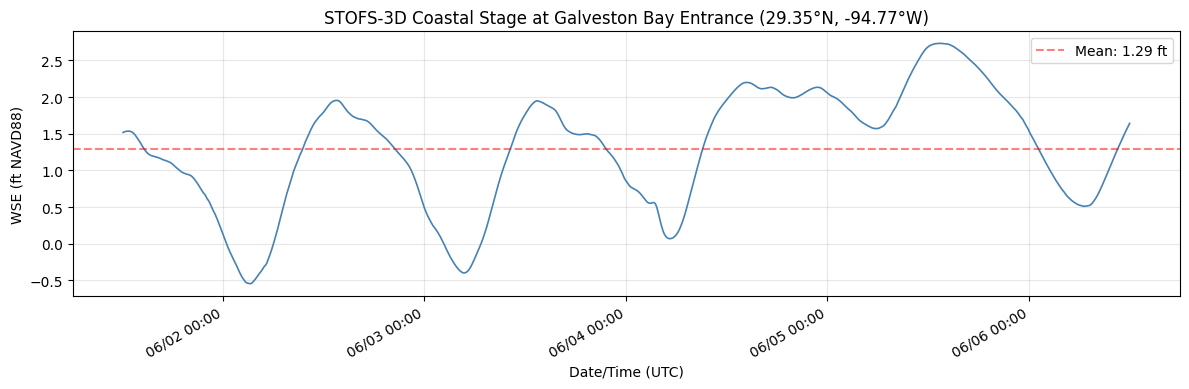


Stage Hydrograph Summary:
  Time steps:  1200
  Duration:    119.9 hours
  Min WSE:     -0.54 ft NAVD88
  Max WSE:     2.73 ft NAVD88
  Mean WSE:    1.29 ft NAVD88


In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(wse_ebfe['datetime'], wse_ebfe['wse_ft'], linewidth=1.2, color='steelblue')
ax.set_xlabel('Date/Time (UTC)')
ax.set_ylabel('WSE (ft NAVD88)')
ax.set_title(f'STOFS-3D Coastal Stage at Galveston Bay Entrance ({galveston_lat}°N, {galveston_lon}°W)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
fig.autofmt_xdate()

ax.axhline(y=wse_ebfe['wse_ft'].mean(), color='red', linestyle='--', alpha=0.5,
           label=f"Mean: {wse_ebfe['wse_ft'].mean():.2f} ft")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nStage Hydrograph Summary:")
print(f"  Time steps:  {len(wse_ebfe)}")
print(f"  Duration:    {(wse_ebfe['datetime'].iloc[-1] - wse_ebfe['datetime'].iloc[0]).total_seconds()/3600:.1f} hours")
print(f"  Min WSE:     {wse_ebfe['wse_ft'].min():.2f} ft NAVD88")
print(f"  Max WSE:     {wse_ebfe['wse_ft'].max():.2f} ft NAVD88")
print(f"  Mean WSE:    {wse_ebfe['wse_ft'].mean():.2f} ft NAVD88")

### Step 6: Inject Stage Boundary Condition into Unsteady File

`CoastalBoundary.generate_stage_bc()` writes the WSE time series into the HEC-RAS `.u##` file at the identified coastal boundary location. It:
- Finds the `Boundary Location=` line matching the BC name
- Writes values in HEC-RAS fixed-width format (8.2f, 10 values/line)
- Updates the `Interval=` line automatically based on time step spacing

> **Datum note**: STOFS-3D uses NAVD88. If the HEC-RAS model uses a different vertical datum, adjust with `datum_adjustment_ft`.

In [15]:
if not RUN_EBFE_MODEL_EDIT_DEMO:
    print("Skipping BC injection in the saved notebook run.")
    print("Set RUN_EBFE_MODEL_EDIT_DEMO = True to write STOFS-3D stages into the organized RAS project.")
elif coastal_bc_name and unsteady_file and unsteady_file.exists():
    print("Injecting STOFS-3D coastal boundary condition:")
    print(f"  BC Location: {coastal_bc_name!r}")
    print(f"  Unsteady file: {unsteady_file.name}")
    print(f"  WSE time steps: {len(wse_ebfe)}")
    print("  Datum adjustment: 0.0 ft (NAVD88 to NAVD88)\n")

    try:
        CoastalBoundary.generate_stage_bc(
            wse_timeseries=wse_ebfe,
            unsteady_file=str(unsteady_file),
            bc_location=coastal_bc_name,
            units="feet",
            datum_adjustment_ft=0.0,
        )
        print("Stage boundary condition written successfully!")
        print(f"Verify by opening {unsteady_file.name} in a text editor")
        print(f"and searching for 'Boundary Location={coastal_bc_name}'")
    except Exception as e:
        print(f"BC injection failed: {e}")
        print("\nThis may indicate the BC location name does not match exactly,")
        print("or the unsteady file does not have a Stage Hydrograph section")
        print("for this boundary. Check boundaries_df output above.")
else:
    print("Skipping BC injection:")
    if not coastal_bc_name:
        print("  - No coastal (stage hydrograph) BC found in model")
    if not unsteady_file or not unsteady_file.exists():
        print(f"  - Unsteady file not found: {unsteady_file}")


Skipping BC injection in the saved notebook run.
Set RUN_EBFE_MODEL_EDIT_DEMO = True to write STOFS-3D stages into the organized RAS project.


### Step 6b: Update Plan and Unsteady File Metadata

Best practice: update plan titles, short identifiers, and descriptions so the model is self-documenting when opened in the HEC-RAS GUI. This leaves behind a well-organized project folder for inspection.

**Disabling precipitation DSS linkage**: The eBFE model's `.u01` file references HMS precipitation excess from a January 2000 DSS file (`InputDSS/100yr.dss`). Our simulation dates are in April 2026 (matching the STOFS-3D forecast), so HEC-RAS cannot find precipitation data for that period and exits immediately. Since this demo is **coastal boundary injection only** (no precipitation forcing), we disable the DSS linkage.

**Step 6c** (next cell) goes further: it removes ALL individual DSS boundary references (`DSS File=` and `DSS Path=` lines) from the `.u01`. The `Use DSS=False` flag only disables the global precipitation DSS — each flow hydrograph BC has its own DSS reference that must be neutralized separately.

In [16]:
from ras_commander import RasPlan, RasUnsteady

if ras_prj_files:
    plan_number = ras.plan_df.iloc[0]["plan_number"]
    prj_name = ras.prj_file.stem
    unsteady_num = ras.plan_df.iloc[0].get("unsteady_number", "01")
    u_file = ras_project / f"{prj_name}.u{str(unsteady_num).zfill(2)}"
    p_file = ras_project / f"{prj_name}.p{str(plan_number).zfill(2)}"

    if not RUN_EBFE_MODEL_EDIT_DEMO:
        print("Skipping plan/unsteady metadata edits in the saved notebook run.")
        print("Set RUN_EBFE_MODEL_EDIT_DEMO = True to modify the organized RAS project files.")
    else:
        RasPlan.set_plan_title(plan_number, "STOFS-3D Coastal BC Demo", ras_object=ras)
        RasPlan.set_shortid(plan_number, "STOFS3D", ras_object=ras)

        description = (
            "North Galveston Bay eBFE model with STOFS-3D coastal boundary "
            "conditions injected at the coastal outlet. Stage hydrograph from "
            "NOAA STOFS-3D-Atlantic forecast (or synthetic tidal signal). "
            "Demonstrates CoastalBoundary.generate_stage_bc() workflow. "
            "See notebook 923_stofs3d_coastal_boundary.ipynb for details."
        )
        RasPlan.update_plan_description(plan_number, description, ras_object=ras)
        RasUnsteady.update_flow_title(str(u_file), "STOFS-3D Coastal BC")

        u_text = u_file.read_text(encoding="utf-8", errors="replace")
        u_text = u_text.replace("Use DSS=True", "Use DSS=False", 1)
        u_file.write_text(u_text, encoding="utf-8")
        print("Disabled precipitation DSS linkage (original data covers Jan 2000 only)")

        p_text = p_file.read_text(encoding="utf-8", errors="replace")
        p_text = p_text.replace("Run HTab=-1", "Run HTab= 0", 1)
        p_file.write_text(p_text, encoding="utf-8")
        print("Set Run HTab=0 (skip geometry preprocessor, use existing .g01.hdf)")

        raw_start = pd.Timestamp(wse_ebfe["datetime"].iloc[0])
        raw_end = pd.Timestamp(wse_ebfe["datetime"].iloc[-1])
        bc_span = raw_end - raw_start
        start_dt = raw_start.floor("30min")
        end_dt = (start_dt + bc_span).floor("30min")
        print(f"Raw STOFS-3D window:  {raw_start} → {raw_end} ({bc_span})")
        print(f"Aligned sim window:   {start_dt} → {end_dt}")
        start_naive = start_dt.to_pydatetime().replace(tzinfo=None)
        end_naive = end_dt.to_pydatetime().replace(tzinfo=None)
        RasPlan.update_simulation_date(plan_number, start_naive, end_naive, ras_object=ras)
        sim_start = start_dt.strftime("%d%b%Y %H:%M").upper()
        sim_end = end_dt.strftime("%d%b%Y %H:%M").upper()
        print("Plan title:  STOFS-3D Coastal BC Demo")
        print("Short ID:    STOFS3D")
        print("Flow title:  STOFS-3D Coastal BC")
        print(f"Simulation:  {sim_start} to {sim_end}")
        print(f"Description: {description[:60]}...")
else:
    print("Skipped - RAS model not available")


Skipping plan/unsteady metadata edits in the saved notebook run.
Set RUN_EBFE_MODEL_EDIT_DEMO = True to modify the organized RAS project files.


In [17]:
# Step 6c: Neutralize HMS-linked DSS flow boundary conditions
# This mutates the unsteady file, so it is opt-in for saved notebook execution.

import re

if not RUN_EBFE_MODEL_EDIT_DEMO:
    print("Skipping DSS neutralization in the saved notebook run.")
elif ras_prj_files:
        u_text = u_file.read_text(encoding='utf-8', errors='replace')

        # Count DSS references before removal
        dss_file_lines = re.findall(r'^DSS File=.*$', u_text, re.MULTILINE)
        dss_path_lines = re.findall(r'^DSS Path=.*$', u_text, re.MULTILINE)

        # Remove all DSS File= and DSS Path= lines
        u_text = re.sub(r'^DSS File=.*\n?', '', u_text, flags=re.MULTILINE)
        u_text = re.sub(r'^DSS Path=.*\n?', '', u_text, flags=re.MULTILINE)

        # For BCs with "Flow Hydrograph= 0" (no inline data, purely DSS-linked),
        # insert a single zero value so HEC-RAS has valid inline data
        u_text = re.sub(
            r'^(Flow Hydrograph=)\s*0\s*$',
            r'\g<1> 1\n    0.00',
            u_text,
            flags=re.MULTILINE
        )

        u_file.write_text(u_text, encoding='utf-8')
        print(f"Neutralized HMS-linked DSS references in {u_file.name}:")
        print(f"  Removed {len(dss_file_lines)} 'DSS File=' lines")
        print(f"  Removed {len(dss_path_lines)} 'DSS Path=' lines")
        for line in dss_file_lines:
            print(f"    {line.strip()}")
        print()
        print("Any purely-DSS BCs (Flow Hydrograph= 0) given inline zero values.")
        print("This prevents 'Error in Loading Unsteady Flow Data' caused by")
        print("DSS files covering Jan 2000 when simulation runs in Apr 2026.")
else:
    print("Skipped - RAS model not available")


Skipping DSS neutralization in the saved notebook run.


### Step 7: Fix File References and Verify Geometry

eBFE models have terrain, land cover, and projection files at different relative locations than the `.rasmap` expects. The North Galveston Bay model's `.rasmap` contains `Filename="..."` references that break after reorganization. We scan ALL references and fix any that don't resolve — this is critical because HEC-RAS 5.0.7's RasGeomWriter.exe requires land cover files even with `Run HTab=0`.

> **Note**: The eBFE delivery includes a pre-processed geometry file (`.g01.hdf`) generated by the original modelers. We preserve this file rather than regenerating it, since geometry preprocessing for 568K cells takes 30+ minutes and requires fully resolved terrain/land cover paths.

In [18]:
import os
import re
import h5py

if not RUN_EBFE_MODEL_EDIT_DEMO:
    print("Skipping .rasmap / geometry-HDF path rewrites in the saved notebook run.")
    print("The organized delivery has already been path-audited; enable RUN_EBFE_MODEL_EDIT_DEMO for repair experiments.")
elif ras_prj_files:
        rasmap_files = list(ras_project.glob('*.rasmap'))
        if rasmap_files:
            rasmap_file = rasmap_files[0]
            rasmap_text = rasmap_file.read_text(encoding='utf-8', errors='replace')

            # Find ALL Filename="..." references
            filename_refs = re.findall(r'Filename="([^"]+)"', rasmap_text)
            print(f"Found {len(filename_refs)} file references in {rasmap_file.name}")

            fixed_count = 0
            for ref_path in sorted(set(filename_refs)):
                resolved = (ras_project / Path(ref_path.replace('\\', '/'))).resolve()

                if resolved.exists():
                    print(f"  [OK] {Path(ref_path).name}")
                    continue

                target_name = Path(ref_path.replace('\\', '/')).name
                candidates = list(organized_folder.rglob(target_name))

                if candidates:
                    actual_file = candidates[0]
                    try:
                        new_rel_path = os.path.relpath(actual_file, ras_project).replace('/', '\\')
                    except ValueError:
                        new_rel_path = str(actual_file).replace('/', '\\')

                    rasmap_text = rasmap_text.replace(
                        f'Filename="{ref_path}"',
                        f'Filename="{new_rel_path}"'
                    )
                    fixed_count += 1
                    print(f"  [FIXED] {target_name}: {ref_path} -> {new_rel_path}")
                else:
                    print(f"  [MISSING] {target_name}: not found in organized folder")

            if fixed_count > 0:
                rasmap_file.write_text(rasmap_text, encoding='utf-8')
                print(f"\nUpdated {rasmap_file.name}: fixed {fixed_count} broken file references")
            else:
                print(f"\nAll file references are valid - no changes needed")
        else:
            print("No .rasmap file found")

        # Fix land cover path in geometry HDF (.g01.hdf)
        # HEC-RAS 5.0.7's RasGeomWriter.exe reads the land cover path from the
        # g01.hdf /Geometry attributes, NOT from the .rasmap. The rasmap fix above
        # is necessary for terrain/projection but insufficient for land cover.
        prj_name = ras.prj_file.stem
        g01_hdf = ras_project / f"{prj_name}.g01.hdf"

        if g01_hdf.exists():
            print(f"\nChecking geometry HDF attributes: {g01_hdf.name}")
            path_attrs = ['Land Cover Filename', 'Terrain Filename']

            with h5py.File(g01_hdf, 'r+') as f:
                geom_group = f.get('Geometry')
                if geom_group is None:
                    print("  No /Geometry group found")
                else:
                    for attr_name in path_attrs:
                        if attr_name not in geom_group.attrs:
                            continue

                        raw = geom_group.attrs[attr_name]
                        attr_val = raw.decode('utf-8') if isinstance(raw, bytes) else str(raw)
                        attr_path = attr_val.strip()

                        if not attr_path:
                            continue

                        resolved = (ras_project / Path(attr_path.replace('\\', '/'))).resolve()
                        if resolved.exists():
                            print(f"  [OK] {attr_name}: {attr_path}")
                            continue

                        target_name = Path(attr_path.replace('\\', '/')).name
                        candidates = list(organized_folder.rglob(target_name))

                        if candidates:
                            actual_file = candidates[0]
                            try:
                                new_rel = os.path.relpath(actual_file, ras_project).replace('/', '\\')
                            except ValueError:
                                new_rel = str(actual_file).replace('/', '\\')

                            geom_group.attrs[attr_name] = new_rel.encode('utf-8')
                            print(f"  [FIXED] {attr_name}: {attr_path} -> {new_rel}")
                        else:
                            print(f"  [MISSING] {attr_name}: {target_name} not found")
        else:
            print(f"\nGeometry HDF not found: {g01_hdf.name}")
else:
    print("Skipped - RAS model not available")


Skipping .rasmap / geometry-HDF path rewrites in the saved notebook run.
The organized delivery has already been path-audited; enable RUN_EBFE_MODEL_EDIT_DEMO for repair experiments.


In [19]:
# Verify pre-processed geometry exists from eBFE delivery
# The .g01.hdf is created by geometry preprocessing and is required for unsteady simulation.
# eBFE deliveries include this file - we preserve it rather than regenerating.

if ras_prj_files:
    prj_name = ras.prj_file.stem
    g01_hdf = ras_project / f"{prj_name}.g01.hdf"
    
    if g01_hdf.exists():
        size_mb = g01_hdf.stat().st_size / 1024 / 1024
        print(f"Pre-processed geometry found: {g01_hdf.name} ({size_mb:.1f} MB)")
        print("Using existing geometry from eBFE delivery (no regeneration needed)")
    else:
        print(f"WARNING: Pre-processed geometry not found: {g01_hdf.name}")
        print("The geometry preprocessor will run as part of the full simulation.")
        print("This requires correct terrain/land cover paths and may take 30+ minutes.")
        print()
        print("If preprocessing fails, check:")
        print("  1. Terrain path in .rasmap resolves correctly")
        print("  2. Land cover path in .rasmap resolves correctly")
        print("  3. Sufficient disk space for 568K cell geometry HDF")
else:
    print("Skipped - RAS model not available")

Pre-processed geometry found: NGB.g01.hdf (160.7 MB)
Using existing geometry from eBFE delivery (no regeneration needed)


### Step 8: Optional Full Unsteady Simulation

This cell can run the complete unsteady simulation with a STOFS-3D coastal boundary condition injected at the outlet, but the saved notebook execution intentionally leaves it disabled. That keeps the committed example deterministic and avoids mutating the organized eBFE project by default.

> **Runtime**: Expect 2-6 hours depending on hardware. The pre-existing geometry preprocessor output (`.g01.hdf`) from the eBFE delivery is used directly when the optional run is enabled. Results are written to a plan HDF file (~1.2 GB).
>
> **Version note**: We use HEC-RAS 5.0.7 because the eBFE delivery's `.g01.hdf` was preprocessed with that version. HEC-RAS 6.x crashes with "Unexpected error; quitting" when loading 5.07-era preprocessed geometry tables. Step 6b sets `Run HTab=0` to skip geometry preprocessing and use the existing tables directly.
>
> **Saved-run interpretation**: With `RUN_FULL_UNSTEADY_SIMULATION = False`, downstream cells inspect existing/current result HDF files only. They do not prove a fresh STOFS-3D-injected HEC-RAS run was executed.

In [20]:
# Version diagnostic: Verify HEC-RAS 5.0.7 is correctly resolved.
# Previous runs showed compute_plan() invoking 6.5 despite init_ras_project("5.0.7").
# This cell detects and corrects the mismatch before execution.

if ras_prj_files:
    current_exe = str(ras.ras_exe_path)
    print(f"ras.ras_exe_path = {current_exe}")

    if "5.0.7" not in current_exe and "5.07" not in current_exe:
        from pathlib import Path as _P
        expected = _P("C:/Program Files (x86)/HEC/HEC-RAS/5.0.7/Ras.exe")
        if expected.exists():
            print(f"WARNING: Wrong version! Overriding to {expected}")
            ras.ras_exe_path = str(expected)
        else:
            print(f"WARNING: Expected 5.0.7 but got {current_exe}")
            print("5.0.7 not found — simulation may crash with")
            print("'Unexpected error; quitting' if .g01.hdf version mismatches.")
    else:
        print("HEC-RAS 5.0.7 correctly resolved — no override needed")
else:
    print("Skipped - RAS model not available")

ras.ras_exe_path = C:\Program Files (x86)\HEC\HEC-RAS\5.0.7\Ras.exe
HEC-RAS 5.0.7 correctly resolved — no override needed


In [21]:
if not RUN_FULL_UNSTEADY_SIMULATION:
    print("Skipping full unsteady simulation in the saved notebook run.")
    print("Set RUN_FULL_UNSTEADY_SIMULATION = True to launch the several-hour HEC-RAS run.")
elif ras_prj_files:
        plan_number = ras.plan_df.iloc[0]['plan_number']
        print(f"Running full unsteady simulation for plan {plan_number}...")
        print(f"  Coastal BC: '{coastal_bc_name}' (STOFS-3D injected)")
        print(f"  Unsteady file: {unsteady_file.name}")
        print(f"  Mesh cells: ~568,000")
        print(f"  Expected runtime: several hours\n")
    
        RasCmdr.compute_plan(plan_number, ras_object=ras, force_rerun=True)
    
        # Refresh project to pick up new HDF results path
        ras = init_ras_project(ras_project, ras_exe)
    
        hdf_result_path = ras.plan_df.iloc[0].get('HDF_Results_Path', None)
        if hdf_result_path and Path(str(hdf_result_path)).exists():
            hdf_size = Path(str(hdf_result_path)).stat().st_size / 1024 / 1024
            print(f"\nSimulation complete!")
            print(f"  HDF results: {Path(str(hdf_result_path)).name} ({hdf_size:.0f} MB)")
        else:
            print("\nWarning: No HDF results found. Check compute messages.")
else:
    print("Skipped - RAS model not available")


Skipping full unsteady simulation in the saved notebook run.
Set RUN_FULL_UNSTEADY_SIMULATION = True to launch the several-hour HEC-RAS run.


### Step 9: Inspect Boundary-Adjacent Results

When the optional full simulation is enabled, this section compares computed WSE near the NGB_Outlet boundary against the injected STOFS-3D stage hydrograph. In the committed notebook run, the optional simulation is disabled, so the cell treats the STOFS-3D hydrograph as a **reference forecast only** and inspects existing/current plan HDFs. It is not a boundary-condition verification unless `RUN_FULL_UNSTEADY_SIMULATION = True`.

Saved run did not execute the optional STOFS-3D HEC-RAS simulation.
Inspecting existing/current HDF results near the outlet; STOFS-3D is shown only as a reference forecast.



2026-06-02 22:55:33 - ras_commander.RasPlan - INFO - Found geometry path: H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203\RAS Model\NGB.g01


Cells nearest to 'NGB_Outlet':
  Cell 565368: 108.4 model units from BC line
  Cell 565160: 114.2 model units from BC line
  Cell 565367: 117.5 model units from BC line
  Cell 565206: 126.6 model units from BC line
  Cell 565222: 134.6 model units from BC line


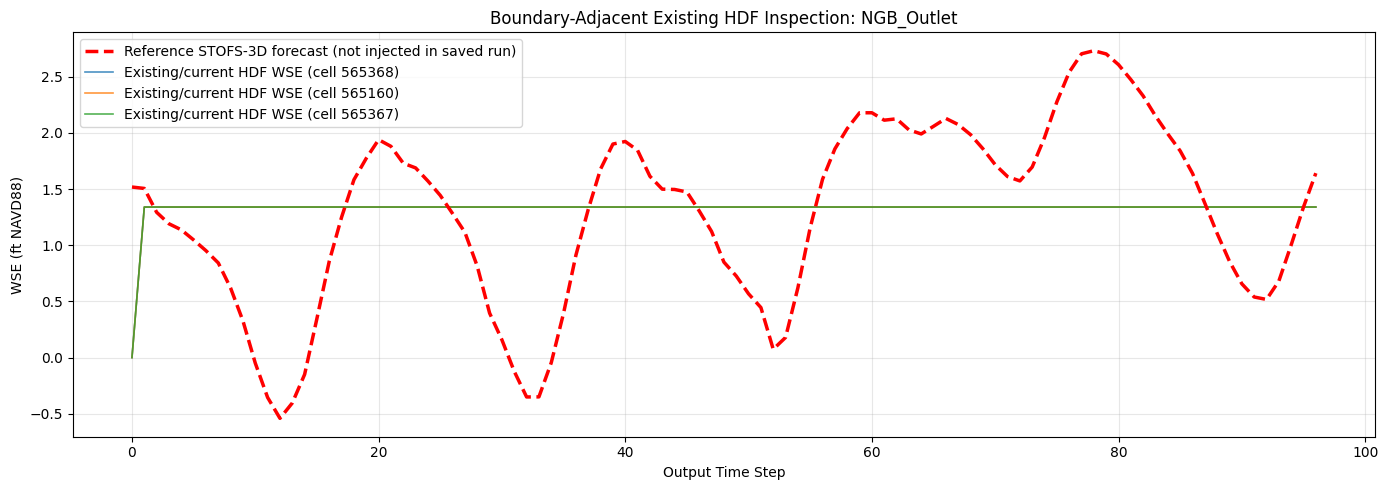


Boundary-adjacent HDF inspection summary:
  Reference STOFS-3D range (not injected): -0.54 to 2.73 ft
  Existing/current HDF cell 565368 WSE range: 0.00 to 1.34 ft
  Existing/current HDF cell 565160 WSE range: 0.00 to 1.34 ft
  Existing/current HDF cell 565367 WSE range: 0.00 to 1.34 ft


In [22]:
from ras_commander.hdf import HdfBndry, HdfMesh
import h5py

# Initialize variables used by Step 10
cell_pts = None
hdf_file = None
mesh_path = None

if ras_prj_files:
    plan_number = ras.plan_df.iloc[0]['plan_number']
    hdf_result_path = ras.plan_df.iloc[0].get('HDF_Results_Path', None)

    if not hdf_result_path or not Path(str(hdf_result_path)).exists():
        print("No HDF results available - skipping boundary-adjacent result inspection")
    else:
        if not RUN_FULL_UNSTEADY_SIMULATION:
            print("Saved run did not execute the optional STOFS-3D HEC-RAS simulation.")
            print("Inspecting existing/current HDF results near the outlet; STOFS-3D is shown only as a reference forecast.\n")

        hdf_file = Path(str(hdf_result_path))

        # Get BC line and mesh cell geometries for spatial matching
        bc_lines = HdfBndry.get_bc_lines(plan_number, ras_object=ras)
        cell_pts = HdfMesh.get_mesh_cell_points(plan_number, ras_object=ras)

        # Find the outlet BC line
        name_col = [c for c in bc_lines.columns if c.lower() == 'name'][0]
        outlet = bc_lines[bc_lines[name_col].str.contains('Outlet', case=False, na=False)]

        if len(outlet) == 0:
            print("Could not find 'Outlet' BC line in geometry")
        else:
            outlet_name = outlet[name_col].iloc[0]
            outlet_geom = outlet.geometry.iloc[0]

            # Find cells nearest to the outlet BC line
            cell_pts['dist_to_outlet'] = cell_pts.geometry.distance(outlet_geom)
            nearest = cell_pts.nsmallest(5, 'dist_to_outlet')
            cell_indices = nearest.index.tolist()

            print(f"Cells nearest to '{outlet_name}':")
            for idx, row in nearest.iterrows():
                print(f"  Cell {idx}: {row['dist_to_outlet']:.1f} model units from BC line")

            # Read WSE time series at boundary cells from HDF
            n_times = None
            wse_at_boundary = None
            reference_resampled = None

            with h5py.File(hdf_file, 'r') as f:
                base = 'Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series/2D Flow Areas'
                areas = list(f[base].keys()) if base in f else []

                if not areas:
                    print("\nNo 2D flow area results found in HDF")
                else:
                    mesh_path = f'{base}/{areas[0]}'
                    wse_ds = f[f'{mesh_path}/Water Surface']
                    n_times = wse_ds.shape[0]
                    # h5py requires fancy indices to be increasing. Read sorted,
                    # then restore nearest-distance order for plotting/reporting.
                    read_indices = sorted(cell_indices)
                    restore_order = [read_indices.index(idx) for idx in cell_indices]
                    wse_at_boundary = wse_ds[:, read_indices][:, restore_order]

                    reference_vals = wse_ebfe['wse_ft'].values
                    reference_resampled = np.interp(
                        np.linspace(0, len(reference_vals) - 1, n_times),
                        np.arange(len(reference_vals)),
                        reference_vals,
                    )

            if n_times is not None:
                fig, ax = plt.subplots(figsize=(14, 5))

                ref_label = (
                    'Injected STOFS-3D Stage BC'
                    if RUN_FULL_UNSTEADY_SIMULATION
                    else 'Reference STOFS-3D forecast (not injected in saved run)'
                )
                ax.plot(range(n_times), reference_resampled, '--', color='red', linewidth=2.5,
                        label=ref_label, zorder=10)

                for i, idx in enumerate(cell_indices[:3]):
                    wse = wse_at_boundary[:, i]
                    valid_mask = wse > -9000
                    if valid_mask.any():
                        ax.plot(np.where(valid_mask)[0], wse[valid_mask],
                                linewidth=1.2, alpha=0.8,
                                label=f'Existing/current HDF WSE (cell {idx})')

                ax.set_xlabel('Output Time Step')
                ax.set_ylabel('WSE (ft NAVD88)')
                title_prefix = 'Boundary Verification' if RUN_FULL_UNSTEADY_SIMULATION else 'Boundary-Adjacent Existing HDF Inspection'
                ax.set_title(f'{title_prefix}: {outlet_name}')
                ax.legend(loc='best')
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

                print("\nBoundary-adjacent HDF inspection summary:")
                if RUN_FULL_UNSTEADY_SIMULATION:
                    print(f"  Optional-run STOFS-3D BC range: {wse_ebfe['wse_ft'].min():.2f} to {wse_ebfe['wse_ft'].max():.2f} ft")
                else:
                    print(f"  Reference STOFS-3D range (not injected): {wse_ebfe['wse_ft'].min():.2f} to {wse_ebfe['wse_ft'].max():.2f} ft")
                for i, idx in enumerate(cell_indices[:3]):
                    wse = wse_at_boundary[:, i]
                    valid = wse[wse > -9000]
                    if len(valid) > 0:
                        print(f"  Existing/current HDF cell {idx} WSE range: {valid.min():.2f} to {valid.max():.2f} ft")
else:
    print("Skipped - RAS model not available")

### Step 10: Inspect Results at Interior Locations

When the optional STOFS-3D simulation is enabled, this section shows how the coastal tidal signal propagates inland through the model domain. In the committed saved run, the full simulation is disabled, so this cell inspects existing/current result HDF output only and labels the plot accordingly.

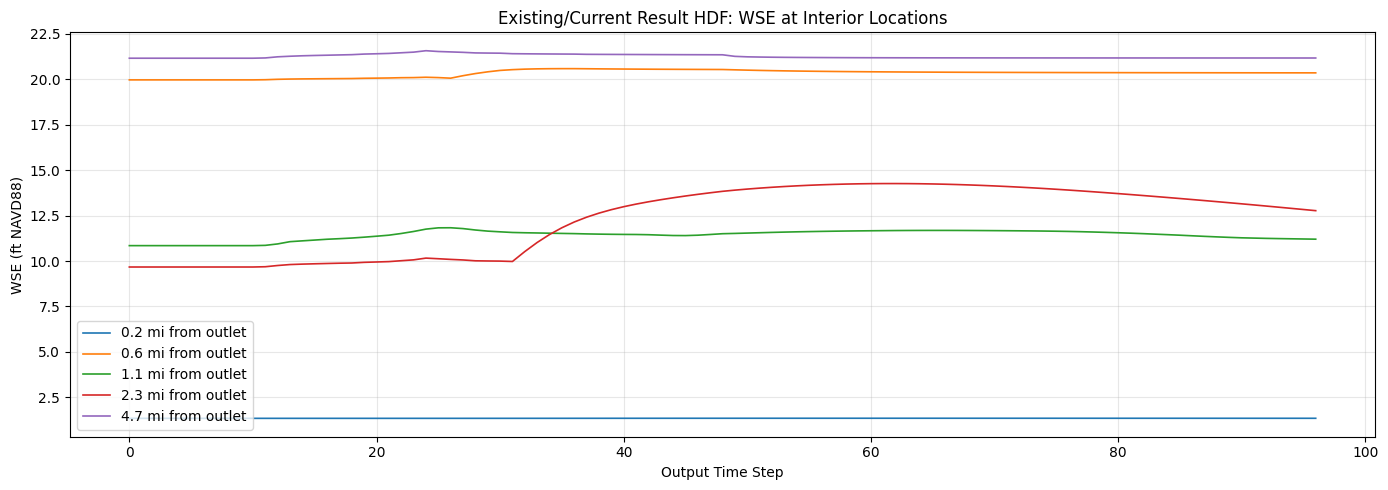

Interior WSE summary:
  0.2 mi: WSE 1.34 to 1.35 ft (tidal range: 0.01 ft)
  0.6 mi: WSE 19.97 to 20.59 ft (tidal range: 0.62 ft)
  1.1 mi: WSE 10.85 to 11.83 ft (tidal range: 0.98 ft)
  2.3 mi: WSE 9.67 to 14.26 ft (tidal range: 4.59 ft)
  4.7 mi: WSE 21.16 to 21.57 ft (tidal range: 0.41 ft)


In [23]:
if ras_prj_files and hdf_result_path and Path(str(hdf_result_path)).exists() and cell_pts is not None and mesh_path is not None:
    try:
        # Select cells at increasing distances from the outlet
        target_distances = [1000, 3000, 6000, 12000, 25000]
        interior_cells = []
        
        for d in target_distances:
            band = cell_pts[(cell_pts['dist_to_outlet'] > d * 0.8) &
                            (cell_pts['dist_to_outlet'] < d * 1.2)]
            if len(band) > 0:
                closest = band.iloc[(band['dist_to_outlet'] - d).abs().argsort()[:1]]
                interior_cells.append(closest.iloc[0])
        
        if interior_cells:
            int_indices = [c.name for c in interior_cells]
            
            with h5py.File(hdf_file, 'r') as f:
                wse_ds = f[f'{mesh_path}/Water Surface']
                read_indices = sorted(int_indices)
                restore_order = [read_indices.index(idx) for idx in int_indices]
                wse_interior = wse_ds[:, read_indices][:, restore_order]
            
            fig, ax = plt.subplots(figsize=(14, 5))
            
            for i, cell in enumerate(interior_cells):
                wse = wse_interior[:, i]
                valid_mask = wse > -9000
                if valid_mask.any():
                    dist_mi = cell['dist_to_outlet'] / 5280
                    ax.plot(np.where(valid_mask)[0], wse[valid_mask],
                            linewidth=1.2,
                            label=f'{dist_mi:.1f} mi from outlet')
            
            ax.set_xlabel('Output Time Step')
            ax.set_ylabel('WSE (ft NAVD88)')
            plot_title = (
                'Tidal Signal Propagation: WSE at Interior Locations'
                if RUN_FULL_UNSTEADY_SIMULATION
                else 'Existing/Current Result HDF: WSE at Interior Locations'
            )
            ax.set_title(plot_title)
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print("Interior WSE summary:")
            for i, cell in enumerate(interior_cells):
                wse = wse_interior[:, i]
                valid = wse[wse > -9000]
                dist_mi = cell['dist_to_outlet'] / 5280
                if len(valid) > 0:
                    tidal_range = valid.max() - valid.min()
                    print(f"  {dist_mi:.1f} mi: WSE {valid.min():.2f} to {valid.max():.2f} ft "
                          f"(tidal range: {tidal_range:.2f} ft)")
                else:
                    print(f"  {dist_mi:.1f} mi: dry (no inundation from tidal forcing alone)")
        else:
            print("Could not find cells at target distances")
    except Exception as e:
        print(f"Interior analysis failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Skipped - no results available or boundary verification did not complete")

### Step 11: Compare Available Plan HDF Results

The eBFE model may include pre-run results for AEP (Annual Exceedance Probability) storm events with full precipitation forcing. When `RUN_FULL_UNSTEADY_SIMULATION = True`, this cell can compare the fresh STOFS-3D tidal-only run against those design storm results.

In the committed saved run, the optional STOFS-3D HEC-RAS simulation is disabled, so this section summarizes existing/current plan HDFs only.

Saved run did not execute the optional STOFS-3D HEC-RAS simulation.
Summarizing existing/current plan HDFs only. Enable RUN_FULL_UNSTEADY_SIMULATION for a fresh injected-boundary run.



2026-06-02 22:55:52 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 567987 rows of summary output data


2026-06-02 22:55:58 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 567987 rows of summary output data


2026-06-02 22:56:04 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 567987 rows of summary output data


2026-06-02 22:56:10 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 567987 rows of summary output data


2026-06-02 22:56:16 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 567987 rows of summary output data


2026-06-02 22:56:22 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 567987 rows of summary output data


2026-06-02 22:56:28 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 567987 rows of summary output data


Existing Plan HDF Comparison
                             Plan  Wet Cells  Max WSE (ft)  Mean WSE (ft)
Existing delivery/current plan 01     567987        120.16          38.65
                            10_YR     567987        119.88          37.98
                           500_YR     567987        120.30          39.27
                            50_YR     567987        120.10          38.43
                            25_YR     567987        120.01          38.23
                      100_YR_PLUS     567987        120.31          39.14
                     100_YR_MINUS     567987        119.86          38.06


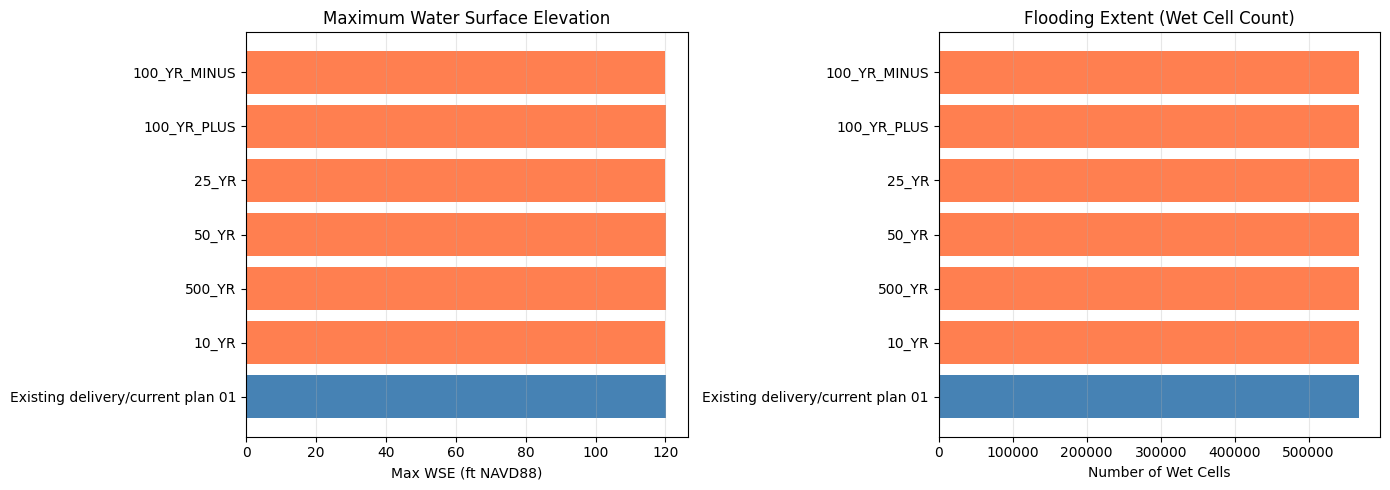


Note: These are existing/current result HDFs from the organized delivery, not a fresh STOFS-3D run.


In [24]:
from ras_commander.hdf import HdfResultsMesh

if ras_prj_files:
    plan_number = ras.plan_df.iloc[0]['plan_number']

    if not RUN_FULL_UNSTEADY_SIMULATION:
        print("Saved run did not execute the optional STOFS-3D HEC-RAS simulation.")
        print("Summarizing existing/current plan HDFs only. Enable RUN_FULL_UNSTEADY_SIMULATION for a fresh injected-boundary run.\n")

    comparison = []
    primary_label = (
        'STOFS-3D (tidal only)'
        if RUN_FULL_UNSTEADY_SIMULATION
        else f"Existing delivery/current plan {plan_number}"
    )

    try:
        primary_max = HdfResultsMesh.get_mesh_max_ws(plan_number, ras_object=ras)
        wse_cols = [c for c in primary_max.columns if 'water' in c.lower() or 'ws' in c.lower()]
        primary_wse_col = wse_cols[0] if wse_cols else primary_max.columns[-1]
        primary_wet = primary_max[primary_max[primary_wse_col] > -9000]

        comparison.append({
            'Plan': primary_label,
            'Wet Cells': len(primary_wet),
            'Max WSE (ft)': float(primary_wet[primary_wse_col].max()),
            'Mean WSE (ft)': float(primary_wet[primary_wse_col].mean())
        })
    except Exception as e:
        print(f"Could not extract primary plan max WSE: {e}")

    # Extract max WSE from each additional delivered/current AEP plan.
    for _, row in ras.plan_df.iterrows():
        pn = row['plan_number']
        title = row.get('Plan Title', pn)
        hdf = row.get('HDF_Results_Path', None)

        if pn == plan_number:
            continue
        if not hdf or not Path(str(hdf)).exists():
            continue

        try:
            aep_max = HdfResultsMesh.get_mesh_max_ws(pn, ras_object=ras)
            wse_cols = [c for c in aep_max.columns if 'water' in c.lower() or 'ws' in c.lower()]
            col = wse_cols[0] if wse_cols else aep_max.columns[-1]
            wet = aep_max[aep_max[col] > -9000]
            comparison.append({
                'Plan': title,
                'Wet Cells': len(wet),
                'Max WSE (ft)': float(wet[col].max()),
                'Mean WSE (ft)': float(wet[col].mean())
            })
        except Exception as e:
            print(f"  {title} (plan {pn}): Could not extract - {e}")

    if len(comparison) > 1:
        comp_df = pd.DataFrame(comparison)
        title = "STOFS-3D vs AEP Design Storm Comparison" if RUN_FULL_UNSTEADY_SIMULATION else "Existing Plan HDF Comparison"
        print(title)
        print("=" * 75)
        print(comp_df.to_string(index=False, float_format='%.2f'))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        colors = ['steelblue'] + ['coral'] * (len(comp_df) - 1)

        axes[0].barh(comp_df['Plan'], comp_df['Max WSE (ft)'], color=colors)
        axes[0].set_xlabel('Max WSE (ft NAVD88)')
        axes[0].set_title('Maximum Water Surface Elevation')
        axes[0].grid(True, alpha=0.3, axis='x')

        axes[1].barh(comp_df['Plan'], comp_df['Wet Cells'], color=colors)
        axes[1].set_xlabel('Number of Wet Cells')
        axes[1].set_title('Flooding Extent (Wet Cell Count)')
        axes[1].grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()

        if RUN_FULL_UNSTEADY_SIMULATION:
            print("\nNote: STOFS-3D represents typical tidal/surge conditions (no precipitation).")
            print("AEP events include both design precipitation and associated storm surge.")
        else:
            print("\nNote: These are existing/current result HDFs from the organized delivery, not a fresh STOFS-3D run.")
    elif comparison:
        print("Only one plan result is available for inspection.")
        print(f"  Plan: {comparison[0]['Plan']}")
        print(f"  Wet cells: {comparison[0]['Wet Cells']}")
        print(f"  Max WSE: {comparison[0]['Max WSE (ft)']:.2f} ft")
    else:
        print("No results available for comparison")
else:
    print("Skipped - RAS model not available")

## Key Takeaways

**What the committed notebook run demonstrated**:
1. **STOFS-3D API**: Download forecasts, extract WSE at coastal points, and convert units
2. **Location comparison**: Galveston Bay (microtidal, Gulf) vs Charleston Harbor (mesotidal, Atlantic)
3. **eBFE delivery access**: Downloaded/cached or reused the organized North Galveston Bay delivery under the shared eBFE workspace
4. **RAS inspection**: Located the organized RAS project, initialized it when extracted, and inspected available/current HDF outputs
5. **Safe defaults**: Left model-file mutation and the several-hour unsteady simulation disabled in the saved run

**What is opt-in**:
- Set `RUN_EBFE_MODEL_EDIT_DEMO = True` to inject STOFS-3D stages, edit plan/unsteady metadata, neutralize DSS flow boundaries, and rewrite path references for experimentation.
- Set `RUN_FULL_UNSTEADY_SIMULATION = True` to launch the full HEC-RAS run and then verify boundary-adjacent WSE against the injected stage hydrograph.
- Run the geometry preprocessor separately as the delivery-format validation gate when checking terrain, land cover, projection, and DSS assembly.

**Important limitations**:
- The committed output does **not** prove a fresh STOFS-3D-injected HEC-RAS simulation was run; it inspects existing/current HDF files unless the optional run flag is enabled.
- The eBFE model is a FEMA AEP study model, **not appropriate for real-time forecasting** without engineering review.
- NOMADS retains only ~2 days of STOFS-3D data; forecasts older than that are unavailable.
- For a complete real-time coastal forecast workflow combining HRRR precipitation + STOFS-3D boundaries, see `examples/915_realtime_forecast_workflow.ipynb`.
- For HMS-to-RAS linked workflows with coastal boundaries, use `hms-commander`.

**Model left in place**: The organized eBFE model is preserved under `H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203\` for GUI inspection.

**Key API methods**:
| Method | Purpose |
|--------|---------|
| `CoastalBoundary.check_availability()` | Check if STOFS-3D forecast is on NOMADS |
| `CoastalBoundary.download_stofs3d()` | Download NetCDF forecast files |
| `CoastalBoundary.extract_wse_at_point()` | Extract WSE time series at lat/lon |
| `CoastalBoundary.generate_stage_bc()` | Write stage hydrograph to a HEC-RAS unsteady flow file |
| `RasEbfeModels.organize_model("north-galveston-bay")` | Download/extract/normalize the eBFE delivery |

In [25]:
import shutil

# Clean up STOFS-3D temporary download data only.
# NOTE: examples/data/stofs3d_gulf is committed sample data and is intentionally
# NOT removed here.
for d in ["example_data/stofs3d_ebfe", "stofs_data"]:
    if Path(d).exists():
        shutil.rmtree(d)
        print(f"Cleaned up: {d}")

for d in ["example_data"]:
    p = Path(d)
    if p.exists() and p.is_dir() and not any(p.iterdir()):
        p.rmdir()
        print(f"Removed empty directory: {d}")

# Leave the shared organized eBFE model in place for GUI inspection.
if organized_folder.exists():
    ras_dirs = list(organized_folder.rglob("*.prj"))
    ras_prj = [p for p in ras_dirs if p.stat().st_size > 100
               and "Proj Title=" in p.read_text(encoding="utf-8", errors="replace")]
    if ras_prj:
        print()
        print("eBFE model available for inspection:")
        print(f"  {ras_prj[0].parent}")
        print(f"  Open {ras_prj[0].name} in HEC-RAS to review coastal BC and metadata")

print()
print("Done!")

Cleaned up: example_data/stofs3d_ebfe
Removed empty directory: example_data



eBFE model available for inspection:
  H:\Testing\eBFE Model Organization\Organized\NorthGalvestonBay_12040203\RAS Model
  Open NGB.prj in HEC-RAS to review coastal BC and metadata

Done!
